<a href="https://colab.research.google.com/github/wsteve16/Intro-to-Machine-Learning/blob/main/ML_HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Problem 1a: exploring learning rates ---
alpha=0.1: diverged at iteration 23
alpha=0.1: ran 24 iterations, last finite train cost = 3.109e+299
alpha=0.05: diverged at iteration 24
alpha=0.05: ran 25 iterations, last finite train cost = 4.623e+298
alpha=0.01: diverged at iteration 27
alpha=0.01: ran 28 iterations, last finite train cost = 3.726e+299
alpha=0.01: diverged at iteration 27
Best alpha (most stable): 0.01
Final theta: [-2.57149881e+153 -1.58799388e+157 -7.73520259e+153 -3.47289293e+153
 -4.72712737e+153 -2.16803798e+153]


/tmp/ipykernel_2793/106463921.py:52: RuntimeWarning: overflow encountered in square
  val_cost = (1 / (2 * n_val)) * np.sum(val_error ** 2)
/tmp/ipykernel_2793/106463921.py:49: RuntimeWarning: overflow encountered in square
  train_cost = (1 / (2 * m)) * np.sum(error ** 2)


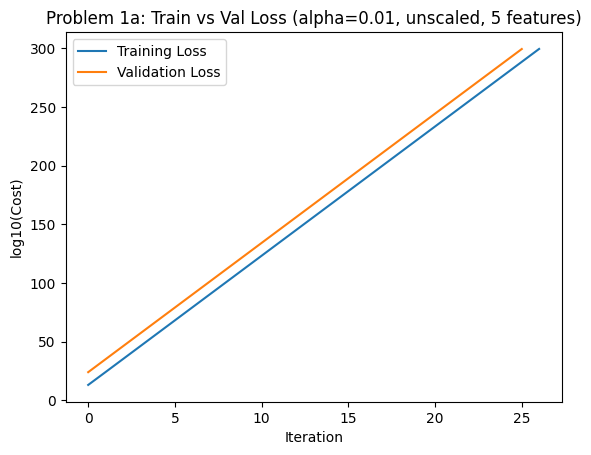

--- Problem 1b: exploring learning rates ---
alpha=0.1: diverged at iteration 23
alpha=0.1: ran 24 iterations, last finite train cost = 3.109e+299
alpha=0.05: diverged at iteration 24
alpha=0.05: ran 25 iterations, last finite train cost = 4.623e+298
alpha=0.01: diverged at iteration 27
alpha=0.01: ran 28 iterations, last finite train cost = 3.726e+299
alpha=0.01: diverged at iteration 27
Best alpha (most stable): 0.01
Final theta: [-2.57150098e+153 -1.58799521e+157 -7.73520911e+153 -3.47289586e+153
 -4.72713136e+153 -2.33609225e+153 -4.92785674e+152 -8.95750200e+152
 -1.10845870e+152 -9.01792317e+152 -2.16803981e+153 -7.00339311e+152]


/tmp/ipykernel_2793/106463921.py:52: RuntimeWarning: overflow encountered in square
  val_cost = (1 / (2 * n_val)) * np.sum(val_error ** 2)
/tmp/ipykernel_2793/106463921.py:49: RuntimeWarning: overflow encountered in square
  train_cost = (1 / (2 * m)) * np.sum(error ** 2)


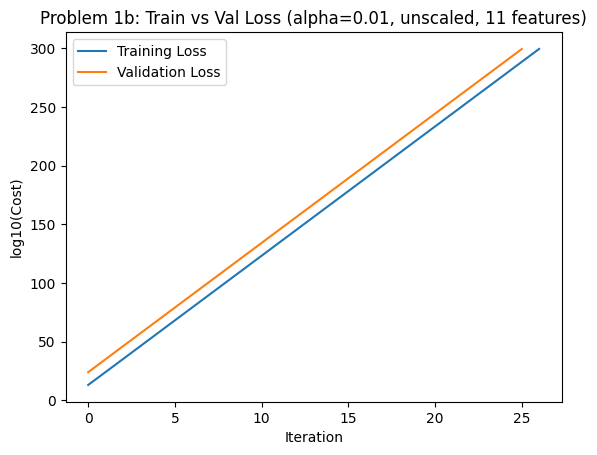

--- Problem 2a: standardization vs normalization ---
standardized final train cost = 7.5754e+11, final val cost = 8.0966e+11
normalized final train cost   = 7.6081e+11, final val cost = 8.1953e+11


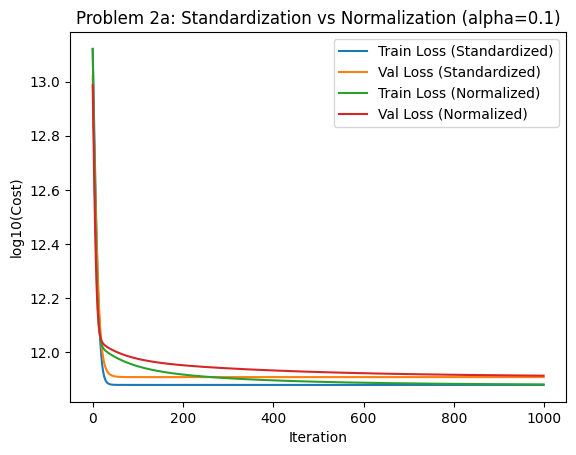

--- Problem 2b: standardization vs normalization ---
standardized final train cost = 5.5666e+11, final val cost = 6.4438e+11
normalized final train cost   = 5.5922e+11, final val cost = 6.4745e+11


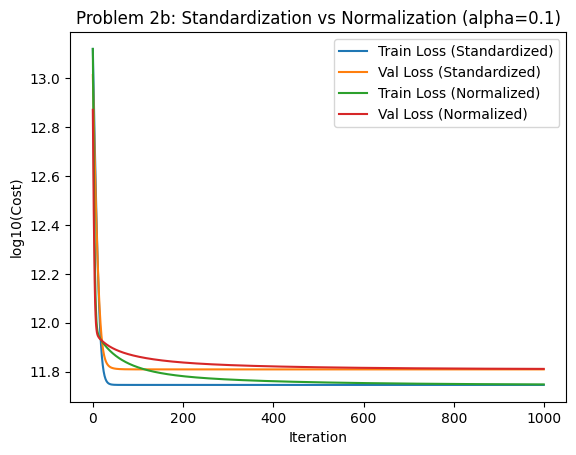

--- Problem 3a: standardized inputs + L2 penalty (lambda=1000) ---
2a (no penalty):   final train cost = 7.5754e+11, final val cost = 8.0966e+11
3a (with penalty): final train cost = 1.3182e+12, final val cost = 1.1106e+12
theta without penalty: [4788865.7  708611.6  129534.6  567924.8  521667.   316300.6]
theta with penalty:    [4788865.7  257472.4  141756.7  233807.7  198573.   163562.3]


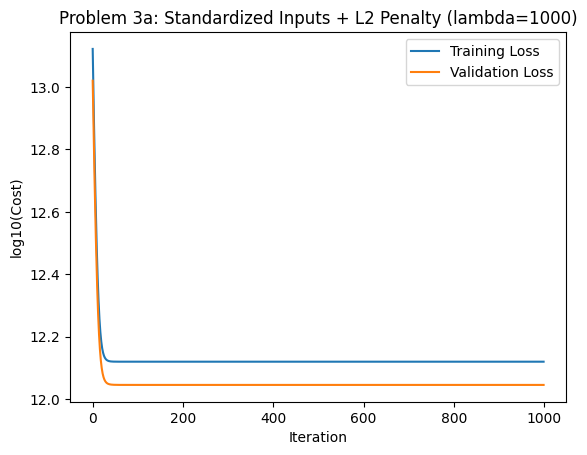

--- Problem 3b: standardized inputs + L2 penalty (lambda=1000) ---
2b (no penalty):   final train cost = 5.5666e+11, final val cost = 6.4438e+11
3b (with penalty): final train cost = 1.1686e+12, final val cost = 8.8799e+11
theta without penalty: [4788865.7  546961.5  114738.7  501290.5  406536.6  164224.4  104614.2
  138713.2  163303.1  453475.2  238056.5  305212.8]
theta with penalty:    [4788865.7  228483.1  131528.   217963.1  179984.2  108516.1   79540.1
   62961.    49109.4  198503.   145088.6  142989.5]


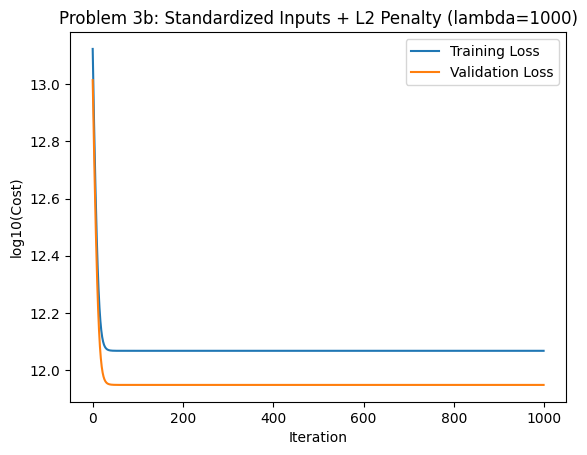

In [9]:
#Intro to Machine Learning
# HW 2

#US Housing dataset - linear regression with gradient descent, from scratch
#80/20 train/validation split used throughout

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

csv_path = 'Housing.csv'
df = pd.read_csv(csv_path)

#convert yes/no columns to 1/0 so they can be used as numeric inputs
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

y = df['price'].values.astype(float)

#80/20 split, same split used for every problem below
np.random.seed(42)
m = len(y)
idx = np.random.permutation(m)
split = int(0.8 * m)
train_idx, val_idx = idx[:split], idx[split:]
y_train, y_val = y[train_idx], y[val_idx]


def gradient_descent(X, y, X_val, y_val, alpha, n):
    m = len(y)
    n_val = len(y_val)

    theta = np.zeros(X.shape[1] + 1)  #thetas initialized to zero, theta[0] is the intercept

    Xb = np.hstack([np.ones((m, 1)), X])
    Xb_val = np.hstack([np.ones((n_val, 1)), X_val])

    train_cost_tracked = []
    val_cost_tracked = []

    for i in range(n):
        predicted = Xb.dot(theta)
        error = predicted - y

        gradient = (1 / m) * Xb.T.dot(error)
        theta = theta - alpha * gradient

        train_cost = (1 / (2 * m)) * np.sum(error ** 2)

        val_error = Xb_val.dot(theta) - y_val
        val_cost = (1 / (2 * n_val)) * np.sum(val_error ** 2)

        train_cost_tracked.append(train_cost)
        val_cost_tracked.append(val_cost)

        if np.isnan(train_cost) or np.isinf(train_cost):
            print(f"alpha={alpha}: diverged at iteration {i}")
            break

    return theta, train_cost_tracked, val_cost_tracked


def plot_log_loss(train_cost_tracked, val_cost_tracked, title):
    #plotting log10(cost) since costs get to ~1e299, which is too big for plt.yscale('log')
    train_plot = [np.log10(c) if np.isfinite(c) and c > 0 else np.nan for c in train_cost_tracked]
    val_plot = [np.log10(c) if np.isfinite(c) and c > 0 else np.nan for c in val_cost_tracked]

    plt.plot(range(len(train_plot)), train_plot, label='Training Loss')
    plt.plot(range(len(val_plot)), val_plot, label='Validation Loss')
    plt.xlabel('Iteration')
    plt.ylabel('log10(Cost)')
    plt.title(title)
    plt.legend()
    plt.show()


n_iterations = 30
alphas = [0.1, 0.05, 0.01]

#1a) area, bedrooms, bathrooms, stories, parking

features_a = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
X_a = df[features_a].values.astype(float)
X_train_a, X_val_a = X_a[train_idx], X_a[val_idx]

#try alpha of 0.1, 0.05, 0.01
print("--- Problem 1a: exploring learning rates ---")
for a in alphas:
    theta_a, train_costs_a, val_costs_a = gradient_descent(X_train_a, y_train, X_val_a, y_val, a, n_iterations)
    last_finite = next((c for c in reversed(train_costs_a) if np.isfinite(c)), None)
    print(f"alpha={a}: ran {len(train_costs_a)} iterations, last finite train cost = {last_finite:.3e}")


best_alpha_a = 0.01
theta_a, train_cost_tracked_a, val_cost_tracked_a = gradient_descent(
    X_train_a, y_train, X_val_a, y_val, best_alpha_a, n_iterations
)

print(f"Best alpha (most stable): {best_alpha_a}")
print(f"Final theta: {theta_a}")

plot_log_loss(train_cost_tracked_a, val_cost_tracked_a,
              f'Problem 1a: Train vs Val Loss (alpha={best_alpha_a}, unscaled, 5 features)')




#1b) area, bedrooms, bathrooms, stories, mainroad, guestroom, basement,
#hotwaterheating, airconditioning, parking, prefarea

features_b = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
              'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea']
X_b = df[features_b].values.astype(float)
X_train_b, X_val_b = X_b[train_idx], X_b[val_idx]

print("--- Problem 1b: exploring learning rates ---")
for a in alphas:
    theta_b, train_costs_b, val_costs_b = gradient_descent(X_train_b, y_train, X_val_b, y_val, a, n_iterations)
    last_finite = next((c for c in reversed(train_costs_b) if np.isfinite(c)), None)
    print(f"alpha={a}: ran {len(train_costs_b)} iterations, last finite train cost = {last_finite:.3e}")

best_alpha_b = 0.01
theta_b, train_cost_tracked_b, val_cost_tracked_b = gradient_descent(
    X_train_b, y_train, X_val_b, y_val, best_alpha_b, n_iterations
)

print(f"Best alpha (most stable): {best_alpha_b}")
print(f"Final theta: {theta_b}")

plot_log_loss(train_cost_tracked_b, val_cost_tracked_b,
              f'Problem 1b: Train vs Val Loss (alpha={best_alpha_b}, unscaled, 11 features)')


#2a) repeat 1a with standardization and normalization

def standardize(X_train, X_val):
    #z-score using TRAIN stats only, so we don't leak info from the val set
    mu = X_train.mean(axis=0)
    sigma = X_train.std(axis=0)
    return (X_train - mu) / sigma, (X_val - mu) / sigma


def normalize(X_train, X_val):
    #min-max using TRAIN stats only
    x_min = X_train.min(axis=0)
    x_max = X_train.max(axis=0)
    return (X_train - x_min) / (x_max - x_min), (X_val - x_min) / (x_max - x_min)


def plot_scaling_comparison(tc_std, vc_std, tc_norm, vc_norm, title):
    def log_safe(costs):
        return [np.log10(c) if np.isfinite(c) and c > 0 else np.nan for c in costs]

    plt.plot(log_safe(tc_std), label='Train Loss (Standardized)')
    plt.plot(log_safe(vc_std), label='Val Loss (Standardized)')
    plt.plot(log_safe(tc_norm), label='Train Loss (Normalized)')
    plt.plot(log_safe(vc_norm), label='Val Loss (Normalized)')
    plt.xlabel('Iteration')
    plt.ylabel('log10(Cost)')
    plt.title(title)
    plt.legend()
    plt.show()


alpha_scaled = 0.1
n_iterations_scaled = 1000

X_train_a_std, X_val_a_std = standardize(X_train_a, X_val_a)
X_train_a_norm, X_val_a_norm = normalize(X_train_a, X_val_a)

theta_a_std, train_cost_a_std, val_cost_a_std = gradient_descent(
    X_train_a_std, y_train, X_val_a_std, y_val, alpha_scaled, n_iterations_scaled)
theta_a_norm, train_cost_a_norm, val_cost_a_norm = gradient_descent(
    X_train_a_norm, y_train, X_val_a_norm, y_val, alpha_scaled, n_iterations_scaled)

print("--- Problem 2a: standardization vs normalization ---")
print(f"standardized final train cost = {train_cost_a_std[-1]:.4e}, final val cost = {val_cost_a_std[-1]:.4e}")
print(f"normalized final train cost   = {train_cost_a_norm[-1]:.4e}, final val cost = {val_cost_a_norm[-1]:.4e}")

plot_scaling_comparison(train_cost_a_std, val_cost_a_std, train_cost_a_norm, val_cost_a_norm,
                         f'Problem 2a: Standardization vs Normalization (alpha={alpha_scaled})')


#2b) repeat 1b with standardization and normalization

X_train_b_std, X_val_b_std = standardize(X_train_b, X_val_b)
X_train_b_norm, X_val_b_norm = normalize(X_train_b, X_val_b)

theta_b_std, train_cost_b_std, val_cost_b_std = gradient_descent(
    X_train_b_std, y_train, X_val_b_std, y_val, alpha_scaled, n_iterations_scaled)
theta_b_norm, train_cost_b_norm, val_cost_b_norm = gradient_descent(
    X_train_b_norm, y_train, X_val_b_norm, y_val, alpha_scaled, n_iterations_scaled)

print("--- Problem 2b: standardization vs normalization ---")
print(f"standardized final train cost = {train_cost_b_std[-1]:.4e}, final val cost = {val_cost_b_std[-1]:.4e}")
print(f"normalized final train cost   = {train_cost_b_norm[-1]:.4e}, final val cost = {val_cost_b_norm[-1]:.4e}")

plot_scaling_comparison(train_cost_b_std, val_cost_b_std, train_cost_b_norm, val_cost_b_norm,
                         f'Problem 2b: Standardization vs Normalization (alpha={alpha_scaled})')


#3a) repeat 2a with an L2 parameter penalty added to the training loss

def gradient_descent_regularized(X, y, X_val, y_val, alpha, n, lam):
    m = len(y)
    n_val = len(y_val)

    theta = np.zeros(X.shape[1] + 1)

    Xb = np.hstack([np.ones((m, 1)), X])
    Xb_val = np.hstack([np.ones((n_val, 1)), X_val])

    train_cost_tracked = []
    val_cost_tracked = []

    for i in range(n):
        predicted = Xb.dot(theta)
        error = predicted - y

        gradient = (1 / m) * Xb.T.dot(error)
        gradient[1:] += (lam / m) * theta[1:]  #don't penalize the intercept
        theta = theta - alpha * gradient

        train_cost = (1 / (2 * m)) * np.sum(error ** 2) + (lam / (2 * m)) * np.sum(theta[1:] ** 2)

        val_error = Xb_val.dot(theta) - y_val
        val_cost = (1 / (2 * n_val)) * np.sum(val_error ** 2)  #no penalty on the val loss

        train_cost_tracked.append(train_cost)
        val_cost_tracked.append(val_cost)

    return theta, train_cost_tracked, val_cost_tracked


lam = 1000

theta_a_reg, train_cost_a_reg, val_cost_a_reg = gradient_descent_regularized(
    X_train_a_std, y_train, X_val_a_std, y_val, alpha_scaled, n_iterations_scaled, lam)

print(f"--- Problem 3a: standardized inputs + L2 penalty (lambda={lam}) ---")
print(f"2a (no penalty):   final train cost = {train_cost_a_std[-1]:.4e}, final val cost = {val_cost_a_std[-1]:.4e}")
print(f"3a (with penalty): final train cost = {train_cost_a_reg[-1]:.4e}, final val cost = {val_cost_a_reg[-1]:.4e}")
print(f"theta without penalty: {np.round(theta_a_std, 1)}")
print(f"theta with penalty:    {np.round(theta_a_reg, 1)}")

plot_log_loss(train_cost_a_reg, val_cost_a_reg,
              f'Problem 3a: Standardized Inputs + L2 Penalty (lambda={lam})')


#3b) repeat 2b with an L2 parameter penalty added to the training loss

theta_b_reg, train_cost_b_reg, val_cost_b_reg = gradient_descent_regularized(
    X_train_b_std, y_train, X_val_b_std, y_val, alpha_scaled, n_iterations_scaled, lam)

print(f"--- Problem 3b: standardized inputs + L2 penalty (lambda={lam}) ---")
print(f"2b (no penalty):   final train cost = {train_cost_b_std[-1]:.4e}, final val cost = {val_cost_b_std[-1]:.4e}")
print(f"3b (with penalty): final train cost = {train_cost_b_reg[-1]:.4e}, final val cost = {val_cost_b_reg[-1]:.4e}")
print(f"theta without penalty: {np.round(theta_b_std, 1)}")
print(f"theta with penalty:    {np.round(theta_b_reg, 1)}")

plot_log_loss(train_cost_b_reg, val_cost_b_reg,
              f'Problem 3b: Standardized Inputs + L2 Penalty (lambda={lam})')

